
# Lab 5: Scrodinger equation with FDM

 **Exercise** : Solve the radial Schrodinger for Hydrogen atom with FDM

 ### Hydrogen radial equation

The H atom has an electron of mass $m$ a $r$ distance to the pronton. The potential energy is given by

$U(r)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$

The Schrodinger's equation for this system is

$$
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r}) + -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r})= E\,\psi(\vec{r})$$

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import eigh_tridiagonal
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh


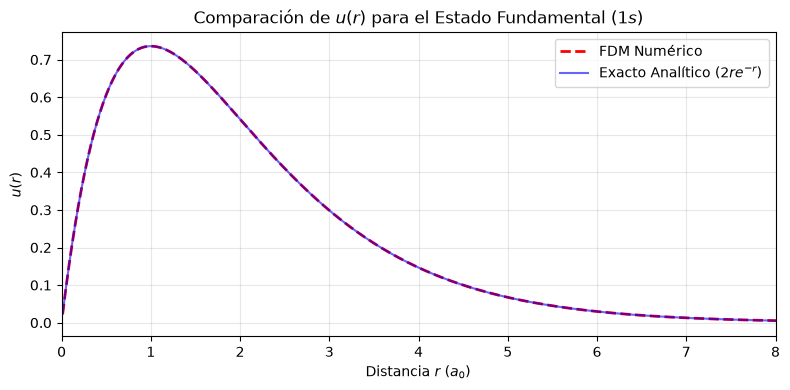

In [14]:
# 1. Solución FDM
r_max, N = 35.0, 3000
r = np.linspace(1e-5, r_max, N)
dr = r[1] - r[0]
r_int = r[1:-1]

V = -1.0 / r_int
diag = 1.0 / (dr**2) + V
off_diag = -0.5 / (dr**2) * np.ones(len(r_int) - 1)

E_fdm, u_fdm = eigh_tridiagonal(diag, off_diag, select='i', select_range=(0, 0))

# Normalización FDM
u1_fdm = u_fdm[:, 0] / np.sqrt(np.trapezoid(u_fdm[:, 0]**2, r_int))

# 2. Solución Analítica Exacta para n=1
u1_exact = 2.0 * r_int * np.exp(-r_int)

# 3. Graficado comparativo
plt.figure(figsize=(8, 4))
plt.plot(r_int, u1_fdm, 'r--', label='FDM Numérico', linewidth=2)
plt.plot(r_int, u1_exact, 'b-', label='Exacto Analítico ($2re^{-r}$)', alpha=0.6)
plt.title('Comparación de $u(r)$ para el Estado Fundamental ($1s$)')
plt.xlabel('Distancia $r$ ($a_0$)')
plt.ylabel('$u(r)$')
plt.xlim(0, 8)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

  n |     E_FDM (Ha) |  E_analitica (Ha) |   E_FDM (eV) | E_analitica (eV) |  error relativo
----------------------------------------------------------------------------------------------------
  1 |    -0.49997189 |       -0.50000000 |   -13.604928 |       -13.605693 |       5.622e-05
  2 |    -0.12499824 |       -0.12500000 |    -3.401375 |        -3.401423 |       1.406e-05
  3 |    -0.05555521 |       -0.05555556 |    -1.511734 |        -1.511744 |       6.247e-06
  4 |    -0.03124804 |       -0.03125000 |    -0.850302 |        -0.850356 |       6.273e-05
  5 |    -0.01959644 |       -0.02000000 |    -0.533246 |        -0.544228 |       2.018e-02
  6 |    -0.00947921 |       -0.01388889 |    -0.257942 |        -0.377936 |       3.175e-01

Figura guardada en hidrogeno_fdm_resultados.png


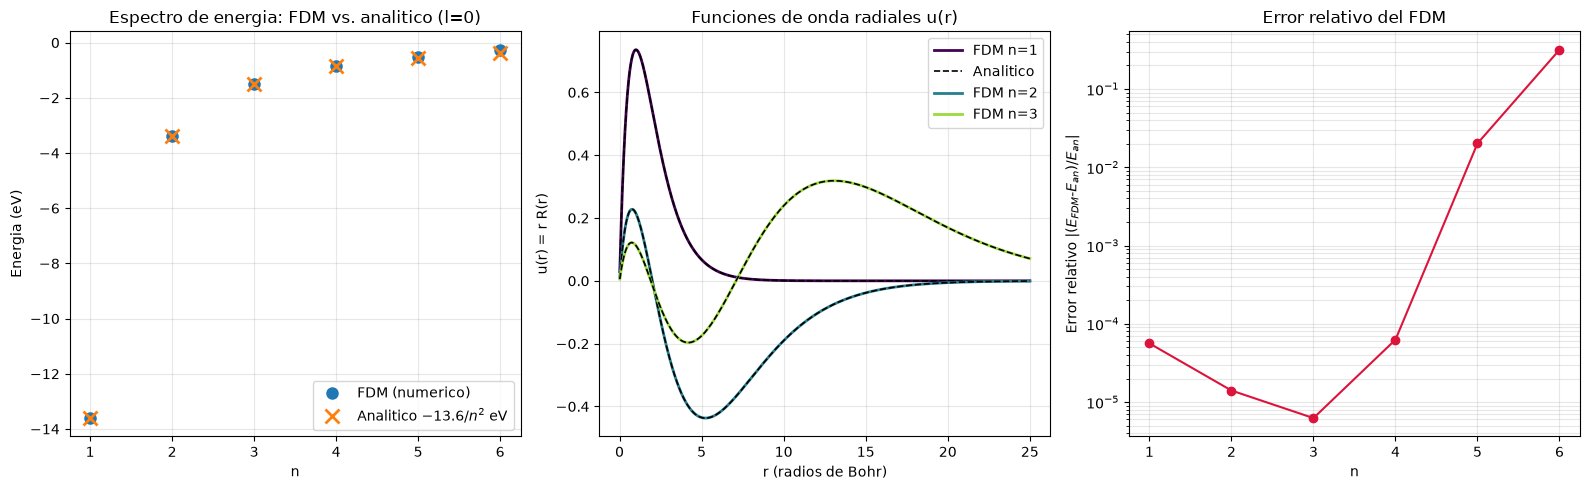

In [17]:
# 1. Parametros numericos

l = 0                 # numero cuantico azimutal 
r_max = 60.0          # radio maximo del dominio (en a0), suficientemente grande
N = 4000              # numero de puntos interiores de la malla
h = r_max / (N + 1)   # paso de la malla

r = np.linspace(h, N * h, N)   # r_i = i*h,  i = 1,...,N  (excluye r=0 y r=r_max)

HARTREE_TO_EV = 27.211386245988

# 2. Construccion del Hamiltoniano por diferencias finitas 
V = l * (l + 1) / (2.0 * r**2) - 1.0 / r      # potencial efectivo

diag_principal = 1.0 / h**2 + V               #  2*(1/(2h^2)) + V
diag_secundaria = -1.0 / (2.0 * h**2) * np.ones(N - 1)

H = diags([diag_secundaria, diag_principal, diag_secundaria],
          offsets=[-1, 0, 1], format="csr")


# 3. Diagonalizacion: valores y vectores propios mas bajos
n_estados = 6
eigvals, eigvecs = eigsh(H, k=n_estados, which="SA")

# ordenar de menor a mayor energia
orden = np.argsort(eigvals)
eigvals = eigvals[orden]
eigvecs = eigvecs[:, orden]

# 4. Solucion analitica para comparar (l = 0  ->  n = l+1, l+2, ... = 1,2,3,...)

n_cuantico = np.arange(l + 1, l + 1 + n_estados)
E_analitica_Ha = -1.0 / (2.0 * n_cuantico**2)

print(f"{'n':>3} | {'E_FDM (Ha)':>14} | {'E_analitica (Ha)':>17} | "
      f"{'E_FDM (eV)':>12} | {'E_analitica (eV)':>16} | {'error relativo':>15}")
print("-" * 100)
for i, n in enumerate(n_cuantico):
    E_num = eigvals[i]
    E_an = E_analitica_Ha[i]
    err = abs((E_num - E_an) / E_an)
    print(f"{n:>3} | {E_num:>14.8f} | {E_an:>17.8f} | "
          f"{E_num*HARTREE_TO_EV:>12.6f} | {E_an*HARTREE_TO_EV:>16.6f} | {err:>15.3e}")

# 5. Normalizacion de las autofunciones numericas: integral |u|^2 dr = 1
for i in range(n_estados):
    norm = np.sqrt(np.trapezoid(eigvecs[:, i]**2, r))
    eigvecs[:, i] /= norm
    # fijar signo: que u sea positiva cerca del origen
    if eigvecs[0, i] < 0:
        eigvecs[:, i] *= -1

# 6. Funciones analiticas u_n(r) = r R_n0(r) para l=0  (n=1,2,3)
def u_analitica(n, r):
    if n == 1:
        R = 2.0 * np.exp(-r)
    elif n == 2:
        R = (1.0 / (2.0 * np.sqrt(2.0))) * (2.0 - r) * np.exp(-r / 2.0)
    elif n == 3:
        R = (2.0 / (81.0 * np.sqrt(3.0))) * (27.0 - 18.0 * r + 2.0 * r**2) * np.exp(-r / 3.0)
    else:
        return None
    return r * R

# 7. Graficas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Espectro de energias: FDM vs analitico
ax = axes[0]
ax.plot(n_cuantico, eigvals * HARTREE_TO_EV, 'o', ms=8, label="FDM (numerico)")
ax.plot(n_cuantico, E_analitica_Ha * HARTREE_TO_EV, 'x', ms=10, mew=2,
        label="Analitico $-13.6/n^2$ eV")
ax.set_xlabel("n")
ax.set_ylabel("Energia (eV)")
ax.set_title("Espectro de energia: FDM vs. analitico (l=0)")
ax.legend()
ax.grid(alpha=0.3)

# (b) Funciones de onda radiales u(r) = r R(r)
ax = axes[1]
r_plot_max = 25
mask = r <= r_plot_max
colors = plt.cm.viridis(np.linspace(0, 0.85, 3))
for idx, n in enumerate([1, 2, 3]):
    u_num = eigvecs[:, idx]
    u_an = u_analitica(n, r)
    ax.plot(r[mask], u_num[mask], color=colors[idx], lw=2, label=f"FDM n={n}")
    ax.plot(r[mask], u_an[mask], '--', color='black', lw=1.2,
            label="Analitico" if idx == 0 else None)
ax.set_xlabel("r (radios de Bohr)")
ax.set_ylabel("u(r) = r R(r)")
ax.set_title("Funciones de onda radiales u(r)")
ax.legend()
ax.grid(alpha=0.3)

# (c) Error relativo de energia vs n
ax = axes[2]
err_rel = np.abs((eigvals - E_analitica_Ha) / E_analitica_Ha)
ax.semilogy(n_cuantico, err_rel, 'o-', color='crimson')
ax.set_xlabel("n")
ax.set_ylabel("Error relativo |($E_{FDM}$-$E_{an}$)/$E_{an}$|")
ax.set_title("Error relativo del FDM")
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
print("\nFigura guardada en hidrogeno_fdm_resultados.png")